In [1]:
import numpy as np
import glob
import os
import re
from tensorflow.keras.preprocessing.image import load_img

data = '/kaggle/input'
files = glob.glob(os.path.join(data, '**/*.tiff'), recursive=True)

num_datos = min(601, len(files))  # Limit to 601 or less if files are fewer
dim = 126
X = np.zeros((num_datos, dim, dim, 3), dtype=np.uint16)
y = np.zeros((num_datos,), dtype=np.float32)

# Regex to extract temp from e.g. "..._003.6C.tiff"
pattern = re.compile(r'_(\d{3}\.\d)C', re.IGNORECASE)

loaded = 0
for i in range(len(files)):
    filename = os.path.basename(files[i])
    match = pattern.search(filename)
    if not match:
        print(f"❌ Skipped (no temp): {filename}")
        continue

    try:
        temp = float(match.group(1))
        img_arr = np.asarray(load_img(files[i], color_mode='grayscale', target_size=(dim, dim)))

        # Replicate grayscale into 3 channels
        X[loaded, :, :, 0] = img_arr
        X[loaded, :, :, 1] = img_arr
        X[loaded, :, :, 2] = img_arr
        y[loaded] = temp
        loaded += 1
        if loaded >= num_datos:
            break
    except Exception as e:
        print(f"❌ Error reading {filename}: {e}")

# Trim arrays to actual loaded size
X = X[:loaded]
y = y[:loaded]

print(f"✅ Loaded {loaded} images and labels into NumPy arrays.")

2025-07-04 16:36:55.743326: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1751647015.954643      35 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1751647016.006863      35 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


✅ Loaded 601 images and labels into NumPy arrays.


In [2]:
import torch
from torch.utils.data import TensorDataset, DataLoader

# Convert NumPy arrays to PyTorch tensors
X_tensor = torch.tensor(X[:, :, :, 0], dtype=torch.float32).unsqueeze(1) / 255.0  # [N, 1, H, W]
y_tensor = torch.tensor(y, dtype=torch.float32)

# Create a PyTorch Dataset and DataLoader
dataset = TensorDataset(X_tensor, y_tensor)
loader = DataLoader(dataset, batch_size=32, shuffle=True)

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import timm
from torch.utils.data import DataLoader, random_split

# === STEP 3: Real MAE Pretraining (custom decoder) ===
class MAEDecoder(nn.Module):
    def __init__(self, encoder_embed_dim, patch_dim, num_patches, hidden_dim=512):
        super().__init__()
        self.decoder = nn.Sequential(
            nn.Linear(encoder_embed_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, patch_dim)
        )

    def forward(self, x):
        return self.decoder(x)

def create_mask(num_patches, mask_ratio=0.75):
    mask = torch.rand(num_patches)
    num_masked = int(mask_ratio * num_patches)
    _, indices = torch.topk(mask, num_masked, largest=False)
    return indices

def patchify(imgs, patch_size):
    B, C, H, W = imgs.shape
    patches = imgs.unfold(2, patch_size, patch_size).unfold(3, patch_size, patch_size)
    patches = patches.permute(0,2,3,1,4,5).reshape(B, -1, patch_size*patch_size*C)
    return patches

# MAE model and decoder
patch_size = 16
num_patches = (dim // patch_size) ** 2
patch_dim = patch_size * patch_size  # grayscale

mae_encoder = timm.create_model('vit_base_patch16_224', pretrained=False, img_size=dim, in_chans=1)
mae_decoder = MAEDecoder(mae_encoder.embed_dim, patch_dim, num_patches)
mae_optimizer = torch.optim.AdamW(list(mae_encoder.parameters()) + list(mae_decoder.parameters()), lr=1e-4)

print("🔁 Starting MAE Pretraining...")
mae_encoder.train()
mae_decoder.train()

for epoch in range(50):
    total_loss = 0
    for imgs, _ in loader:
        B = imgs.size(0)
        imgs = imgs.to(torch.float32)

        patches = patchify(imgs, patch_size)  # [B, N, patch_dim]
        mask_indices = [create_mask(num_patches) for _ in range(B)]

        visible_patches, target_patches = [], []
        for i in range(B):
            mask = mask_indices[i]
            visible = torch.ones(num_patches, dtype=torch.bool)
            visible[mask] = False
            visible_patches.append(patches[i][visible])
            target_patches.append(patches[i][mask])

        visible_patches = torch.stack([F.pad(v, (0,0,0,num_patches - v.shape[0])) for v in visible_patches])
        target_patches = torch.stack([F.pad(t, (0,0,0,num_patches - t.shape[0])) for t in target_patches])

        x = mae_encoder.patch_embed(imgs)
        x = mae_encoder.blocks(x)
        x = mae_decoder(x)

        loss = F.mse_loss(x, target_patches)
        mae_optimizer.zero_grad()
        loss.backward()
        mae_optimizer.step()
        total_loss += loss.item()

    print(f"Epoch {epoch}: MAE Loss = {total_loss:.4f}")
    
print("✅ MAE Pretraining Complete.\n")

🔁 Starting MAE Pretraining...
Epoch 0: MAE Loss = 0.9861
Epoch 1: MAE Loss = 0.3275
Epoch 2: MAE Loss = 0.2915
Epoch 3: MAE Loss = 0.2593
Epoch 4: MAE Loss = 0.2384
Epoch 5: MAE Loss = 0.2300
Epoch 6: MAE Loss = 0.2184
Epoch 7: MAE Loss = 0.2172
Epoch 8: MAE Loss = 0.2039
Epoch 9: MAE Loss = 0.1991
Epoch 10: MAE Loss = 0.1920
Epoch 11: MAE Loss = 0.1908
Epoch 12: MAE Loss = 0.1897
Epoch 13: MAE Loss = 0.1891
Epoch 14: MAE Loss = 0.1853
Epoch 15: MAE Loss = 0.1898
Epoch 16: MAE Loss = 0.1890
Epoch 17: MAE Loss = 0.1876
Epoch 18: MAE Loss = 0.1843
Epoch 19: MAE Loss = 0.1870
Epoch 20: MAE Loss = 0.1841
Epoch 21: MAE Loss = 0.1848
Epoch 22: MAE Loss = 0.1855
Epoch 23: MAE Loss = 0.1824
Epoch 24: MAE Loss = 0.1822
Epoch 25: MAE Loss = 0.1820
Epoch 26: MAE Loss = 0.1842
Epoch 27: MAE Loss = 0.1819
Epoch 28: MAE Loss = 0.1818
Epoch 29: MAE Loss = 0.1816
Epoch 30: MAE Loss = 0.1817
Epoch 31: MAE Loss = 0.1832
Epoch 32: MAE Loss = 0.1813
Epoch 33: MAE Loss = 0.1829
Epoch 34: MAE Loss = 0.1899


In [4]:
# Split TensorDataset into train and val
train_size = int(0.8 * len(dataset))
train_set, val_set = random_split(dataset, [train_size, len(dataset) - train_size])

# Dataloaders
train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
val_loader = DataLoader(val_set, batch_size=32)

In [5]:
# === STEP 5: Define PrionViT Model ===
class PrionViT(nn.Module):
    def __init__(self, encoder, dim_out=1):
        super().__init__()
        self.encoder = encoder
        self.memory_token = nn.Parameter(torch.zeros(1, encoder.embed_dim))
        self.regressor = nn.Sequential(
            nn.LayerNorm(encoder.embed_dim),
            nn.Linear(encoder.embed_dim, 256),
            nn.ReLU(),
            nn.Linear(256, dim_out)
        )

    def forward(self, x):
        B = x.size(0)
        x = self.encoder.patch_embed(x)
        mem = self.memory_token.expand(B, -1).unsqueeze(1)
        x = torch.cat([mem, x], dim=1)
        x = self.encoder.blocks(x)
        x = x[:, 0]
        return self.regressor(x).squeeze()

# Init model & optimizer
reg_model = PrionViT(mae_encoder)
criterion = nn.L1Loss()
optimizer = torch.optim.AdamW(reg_model.parameters(), lr=1e-4)

In [6]:
# === STEP 6: Fine-tuning ===
print("\n🎯 Starting Regression Fine-Tuning...")
for epoch in range(50):
    total_loss = 0
    for imgs, labels in train_loader:
        preds = reg_model(imgs)
        loss = criterion(preds, labels.float())
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch}: Temp MAE = {total_loss/len(train_loader):.4f}")


🎯 Starting Regression Fine-Tuning...
Epoch 0: Temp MAE = 54.4949
Epoch 1: Temp MAE = 50.8542
Epoch 2: Temp MAE = 47.7726
Epoch 3: Temp MAE = 44.4894
Epoch 4: Temp MAE = 41.2291
Epoch 5: Temp MAE = 38.2460
Epoch 6: Temp MAE = 35.6769
Epoch 7: Temp MAE = 33.8408
Epoch 8: Temp MAE = 32.3723
Epoch 9: Temp MAE = 31.3645
Epoch 10: Temp MAE = 30.7547
Epoch 11: Temp MAE = 30.3718
Epoch 12: Temp MAE = 30.2083
Epoch 13: Temp MAE = 29.7345
Epoch 14: Temp MAE = 29.2943
Epoch 15: Temp MAE = 30.1574
Epoch 16: Temp MAE = 30.0485
Epoch 17: Temp MAE = 28.3097
Epoch 18: Temp MAE = 27.1928
Epoch 19: Temp MAE = 15.3600
Epoch 20: Temp MAE = 11.9812
Epoch 21: Temp MAE = 8.3783
Epoch 22: Temp MAE = 5.8836
Epoch 23: Temp MAE = 3.8441
Epoch 24: Temp MAE = 7.1380
Epoch 25: Temp MAE = 5.6937
Epoch 26: Temp MAE = 3.8017
Epoch 27: Temp MAE = 3.6473
Epoch 28: Temp MAE = 2.9057
Epoch 29: Temp MAE = 2.0753
Epoch 30: Temp MAE = 2.8836
Epoch 31: Temp MAE = 2.3651
Epoch 32: Temp MAE = 2.0657
Epoch 33: Temp MAE = 2.0676

In [8]:
# === STEP 7: Export Predictions to CSV ===
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pandas as pd

reg_model.eval()
y_true, y_pred = [], []
with torch.no_grad():
    for imgs, labels in val_loader:
        preds = reg_model(imgs)
        y_true.extend(labels.numpy())
        y_pred.extend(preds.numpy())

mae = mean_absolute_error(y_true, y_pred)
rmse = mean_squared_error(y_true, y_pred, squared=False)
r2 = r2_score(y_true, y_pred)

print("\n📊 Eval Metrics:")
print(f"MAE:  {mae:.2f} °C")
print(f"RMSE: {rmse:.2f} °C")
print(f"R²:   {r2:.4f}")

df = pd.DataFrame({
    'Index': list(range(len(y_true))),
    'TrueTemperature': y_true,
    'PredictedTemperature': y_pred
})
df.to_csv('/kaggle/working/predictions.csv', index=False)
print("✅ CSV exported to /kaggle/working/predictions11.csv")


📊 Eval Metrics:
MAE:  1.19 °C
RMSE: 1.38 °C
R²:   0.9984
✅ CSV exported to /kaggle/working/predictions11.csv


In [9]:
from sklearn.metrics import (
    mean_absolute_percentage_error,
    median_absolute_error,
    explained_variance_score,
    max_error
)

# Calculate additional metrics
mape = mean_absolute_percentage_error(y_true, y_pred)
medae = median_absolute_error(y_true, y_pred)
expl_var = explained_variance_score(y_true, y_pred)
max_err = max_error(y_true, y_pred)

# Print them
print("\n📊 Additional Metrics:")
print(f"MAPE:           {mape:.4f} %")
print(f"Median AE:      {medae:.4f} °C")
print(f"Explained Var:  {expl_var:.4f}")
print(f"Max Error:      {max_err:.4f} °C")


📊 Additional Metrics:
MAPE:           0.0645 %
Median AE:      1.1853 °C
Explained Var:  0.9988
Max Error:      2.7940 °C


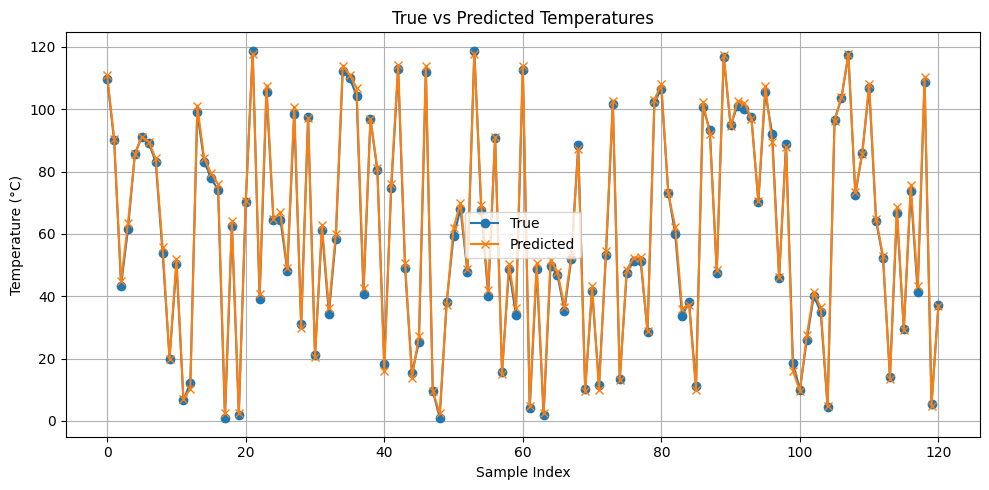

In [10]:
#True vs Predicted (Line Plot)

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(y_true, label="True", marker='o')
plt.plot(y_pred, label="Predicted", marker='x')
plt.title("True vs Predicted Temperatures")
plt.xlabel("Sample Index")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

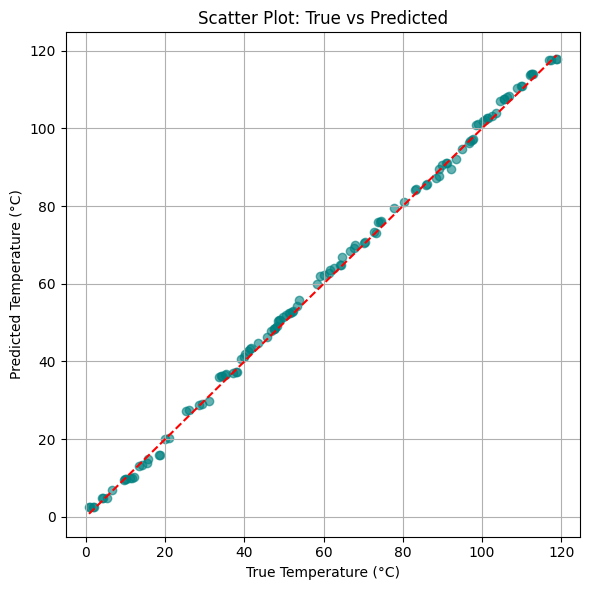

In [11]:
# Scatter Plot (Predicted vs True)

plt.figure(figsize=(6, 6))
plt.scatter(y_true, y_pred, alpha=0.6, color='teal')
plt.plot([min(y_true), max(y_true)], [min(y_true), max(y_true)], color='red', linestyle='--')
plt.xlabel("True Temperature (°C)")
plt.ylabel("Predicted Temperature (°C)")
plt.title("Scatter Plot: True vs Predicted")
plt.grid(True)
plt.tight_layout()
plt.show()

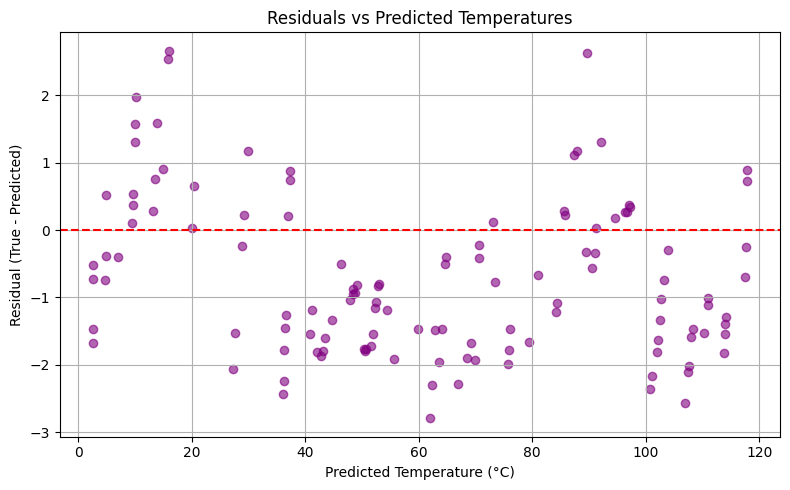

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# ✅ Convert list to NumPy arrays
y_true_np = np.array(y_true)
y_pred_np = np.array(y_pred)

# ✅ Compute residuals
residuals = y_true_np - y_pred_np

# ✅ Plot residuals
plt.figure(figsize=(8, 5))
plt.scatter(y_pred_np, residuals, alpha=0.6, color='purple')
plt.axhline(0, color='red', linestyle='--')
plt.title("Residuals vs Predicted Temperatures")
plt.xlabel("Predicted Temperature (°C)")
plt.ylabel("Residual (True - Predicted)")
plt.grid(True)
plt.tight_layout()
plt.show()

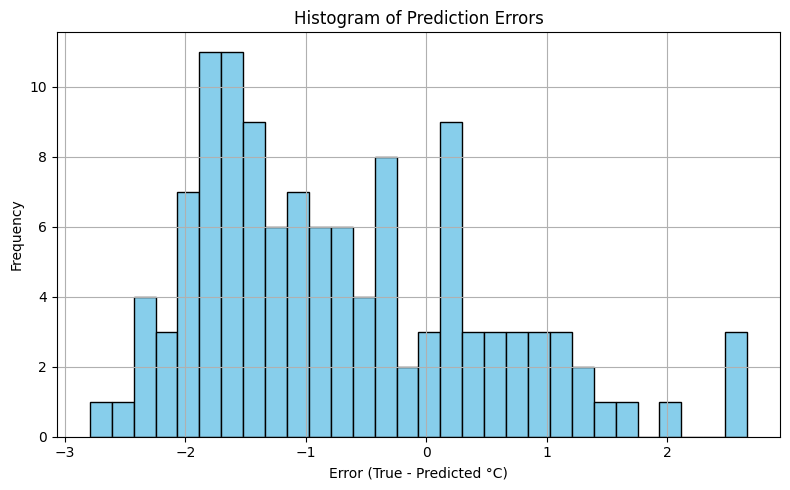

In [20]:
import matplotlib.pyplot as plt

errors = y_true_np - y_pred_np
plt.figure(figsize=(8, 5))
plt.hist(errors, bins=30, color='skyblue', edgecolor='black')
plt.title("Histogram of Prediction Errors")
plt.xlabel("Error (True - Predicted °C)")
plt.ylabel("Frequency")
plt.grid(True)
plt.tight_layout()
plt.show()

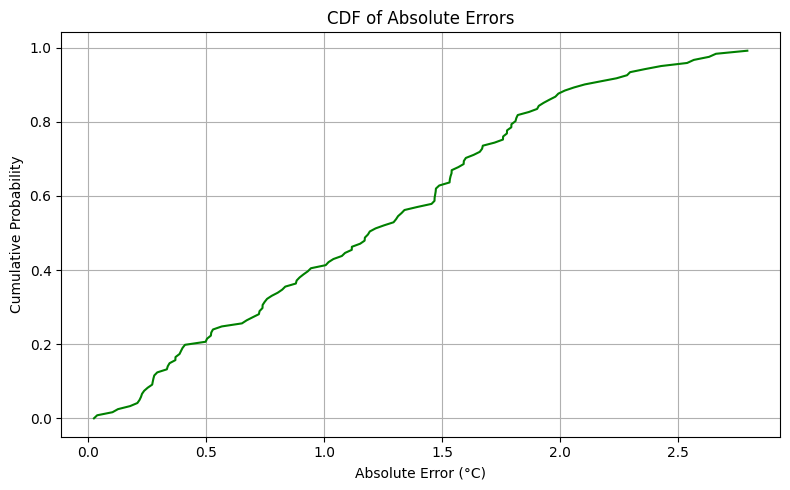

In [21]:
sorted_errors = np.sort(np.abs(errors))
cdf = np.arange(len(errors)) / float(len(errors))

plt.figure(figsize=(8, 5))
plt.plot(sorted_errors, cdf, color='green')
plt.title("CDF of Absolute Errors")
plt.xlabel("Absolute Error (°C)")
plt.ylabel("Cumulative Probability")
plt.grid(True)
plt.tight_layout()
plt.show()

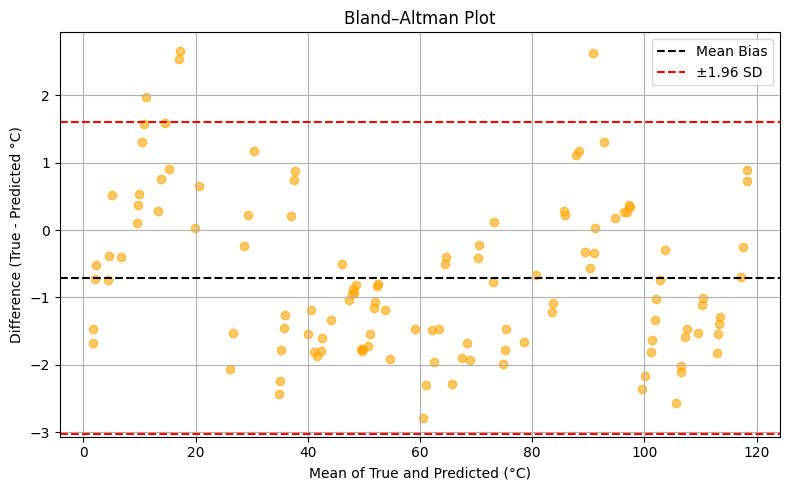

In [22]:
mean_vals = (y_true_np + y_pred_np) / 2
diffs = y_true_np - y_pred_np

plt.figure(figsize=(8, 5))
plt.scatter(mean_vals, diffs, alpha=0.6, color='orange')
plt.axhline(np.mean(diffs), color='black', linestyle='--', label='Mean Bias')
plt.axhline(np.mean(diffs) + 1.96*np.std(diffs), color='red', linestyle='--', label='±1.96 SD')
plt.axhline(np.mean(diffs) - 1.96*np.std(diffs), color='red', linestyle='--')
plt.title("Bland–Altman Plot")
plt.xlabel("Mean of True and Predicted (°C)")
plt.ylabel("Difference (True - Predicted °C)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [23]:
from scipy.stats import pearsonr, spearmanr

pearson_corr, _ = pearsonr(y_true_np, y_pred_np)
spearman_corr, _ = spearmanr(y_true_np, y_pred_np)

print(f"📈 Pearson Correlation:  {pearson_corr:.4f}")
print(f"📈 Spearman Correlation: {spearman_corr:.4f}")

📈 Pearson Correlation:  0.9994
📈 Spearman Correlation: 0.9999


/tmp/ipykernel_35/3534592159.py:8: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


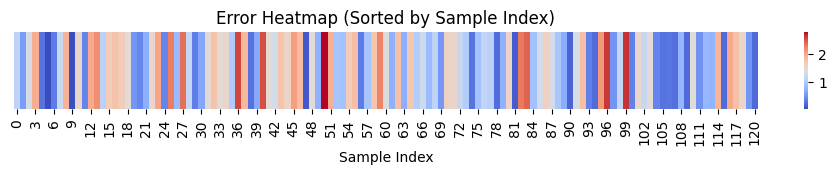

In [24]:
import seaborn as sns

plt.figure(figsize=(12, 1))
sns.heatmap(np.expand_dims(np.abs(errors), axis=0), cmap='coolwarm', cbar=True)
plt.title("Error Heatmap (Sorted by Sample Index)")
plt.xlabel("Sample Index")
plt.yticks([], [])
plt.tight_layout()
plt.show()

In [44]:
import matplotlib.pyplot as plt
import numpy as np

def show_mask_overlay(img, mask_idx, patch_size=16, idx=0):
    img_np = img.squeeze().cpu().numpy()
    mask_map = np.zeros_like(img_np)

    H = W = img_np.shape[0] // patch_size
    for idx_ in mask_idx:
        row = idx_ // W
        col = idx_ % W
        mask_map[row*patch_size:(row+1)*patch_size, col*patch_size:(col+1)*patch_size] = 1

    plt.figure(figsize=(5, 5))
    plt.imshow(img_np, cmap='gray')
    plt.imshow(mask_map, cmap='Reds', alpha=0.4)
    plt.title("Overlay of Masked Patches")
    plt.axis('off')
    plt.tight_layout()

    # ✅ Save instead of show
    plt.savefig(f"/kaggle/working/mask_overlay_{idx}.png")
    plt.close()

In [43]:
show_mask_overlay(imgs[0], mask_idx, patch_size=16, idx=0)